In [8]:
# Q3. Feature Engineering and Regression Pipeline

# Task 1. Date Feature Engineering 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Loading Data
retail_promotions = pd.read_csv('data/q3_retail_promotions.csv')

# Ensuring column is in datetime format
retail_promotions['transaction_date'] = pd.to_datetime(retail_promotions['transaction_date'])

# Extracting year, month, day of week
retail_promotions['year'] = retail_promotions['transaction_date'].dt.year
retail_promotions['month'] = retail_promotions['transaction_date'].dt.month
retail_promotions['week'] = retail_promotions['transaction_date'].dt.day_of_week

# Creating additional binary feature 'is_month_end'
retail_promotions['is_month_end'] = (retail_promotions['transaction_date'].dt.day >=25).astype(int)

# Displaying Sample
print(retail_promotions.head())


  transaction_date  store_id store_size location_type  promotion_type  \
0       2022-01-01        28      small    semi-urban       free_gift   
1       2022-01-01         5     medium    semi-urban       free_gift   
2       2022-01-02        13      small    semi-urban  loyalty_points   
3       2022-01-02        17      small         urban       free_gift   
4       2022-01-03        50     medium    semi-urban            bogo   

   is_weekend  is_festival  competition_density  items_sold  year  month  \
0           1            0                    5         224  2022      1   
1           1            1                    1         348  2022      1   
2           1            0                    6         249  2022      1   
3           1            0                    7         259  2022      1   
4           0            0                    3         277  2022      1   

   week  is_month_end  
0     5             0  
1     5             0  
2     6             0  
3     6 

In [9]:
# Task 2. Temporal Train-Test Split

# Sorting the data by 'transaction_date'
retail_promotions = retail_promotions.sort_values(by = 'transaction_date').reset_index(drop=True)

# Splitting data into train and test
split_index = int(len(retail_promotions)*0.8)

test_retail_promotions = retail_promotions.iloc[split_index:]   # Recent 20% records considered for test
train_retail_promotions = retail_promotions.iloc[:split_index]  # Remaining 80% data considered for train


A random split is not suitable for time-based data because it mixes old and new reocrds together. This means the model might learn from future data, which would not be available in real situations. Using a time-based split ensures the model learns from the past data and is tested on newer data, making the results more realistic.

In [11]:
# Task 3. Preprocessing Pipeline

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline

categorical_cols = ['promotion_type','location_type','store_size']
numerical_cols = retail_promotions.select_dtypes(include = 'number').columns

# Removing the target column
numerical_cols = numerical_cols.drop('items_sold')    

preprocessor = make_column_transformer(
    (OneHotEncoder(drop='first',handle_unknown='ignore',sparse_output=False),categorical_cols),
    (StandardScaler(),numerical_cols),
    verbose_feature_names_out=False
)

print("Preprocessor ready. It will be fitted inside each model pipeline and validation fold.")

Preprocessor ready. It will be fitted inside each model pipeline and validation fold.



------Linear Regression Model------
Linear Regression RMSE: 27.12
Linear Regression MAE: 21.05


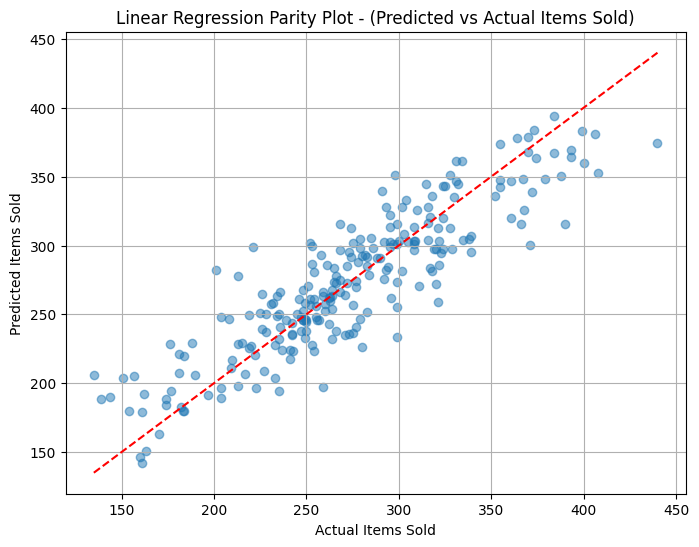

In [12]:
# Task 4. Model Training and Evaluation

# -------- TRAIN DATA --------
X_train = train_retail_promotions.drop(columns = ['items_sold','transaction_date'])
y_train = train_retail_promotions['items_sold']

# -------- TEST DATA --------
X_test = test_retail_promotions.drop(columns = ['items_sold','transaction_date'])
y_test = test_retail_promotions['items_sold']

from sklearn.metrics import mean_absolute_error, mean_squared_error

## Linear Regression

print('\n------Linear Regression Model------')

from sklearn.linear_model import LinearRegression

lr_model = make_pipeline(
    preprocessor,
    LinearRegression()
)

### Training the model
lr_model.fit(X_train,y_train)  

### -- Predicting
y_pred_lr = lr_model.predict(X_test)

### -- Evaluating RMSE
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print(f"Linear Regression RMSE: {round(rmse_lr, 2)}")

### -- Evaluating MAE
mae_lr = mean_absolute_error(y_test,y_pred_lr)
print(f"Linear Regression MAE: {round(mae_lr, 2)}")

### -- Parity Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Actual Items Sold')
plt.ylabel('Predicted Items Sold')
plt.title('Linear Regression Parity Plot - (Predicted vs Actual Items Sold)')
plt.grid(True)
plt.show()





------Random Forest Regressor------
Random Forest RMSE: 31.66
Random Forest MAE: 24.87


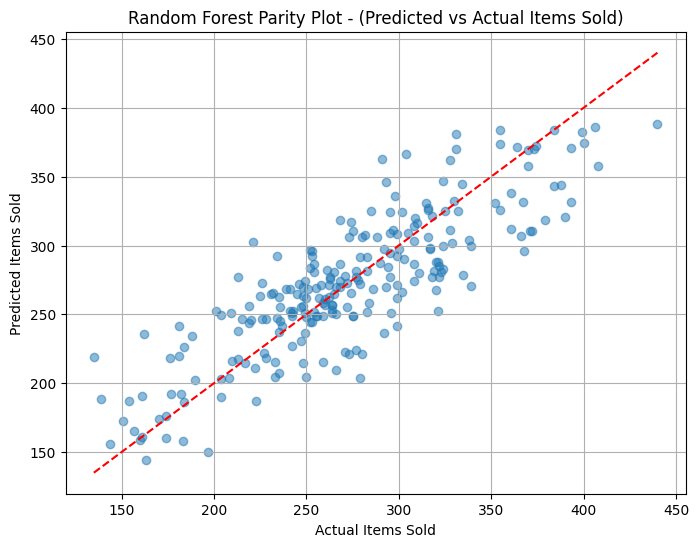

In [13]:
## Random Forest Regressor

print('\n------Random Forest Regressor------')

from sklearn.ensemble import RandomForestRegressor

rf_model = make_pipeline(
    preprocessor,
    RandomForestRegressor(n_estimators=100, random_state=42)
)

### Training the model
rf_model.fit(X_train,y_train)  

### -- Predicting
y_pred_rf = rf_model.predict(X_test)

### -- Evaluating RMSE
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print(f"Random Forest RMSE: {round(rmse_rf, 2)}")

### -- Evaluating MAE
mae_rf = mean_absolute_error(y_test,y_pred_rf)
print(f"Random Forest MAE: {round(mae_rf, 2)}")

### -- Parity Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Actual Items Sold')
plt.ylabel('Predicted Items Sold')
plt.title('Random Forest Parity Plot - (Predicted vs Actual Items Sold)')
plt.grid(True)
plt.show()

                          feature  importance
7                store_size_small    0.183954
10                    is_festival    0.174477
5             location_type_urban    0.140498
14                           week    0.090612
9                      is_weekend    0.063547
8                        store_id    0.062056
6               store_size_medium    0.058178
11            competition_density    0.053486
13                          month    0.040473
4        location_type_semi-urban    0.038886
3   promotion_type_loyalty_points    0.031470
12                           year    0.017783
0   promotion_type_category_offer    0.016839
2        promotion_type_free_gift    0.011558
1    promotion_type_flat_discount    0.010469
15                   is_month_end    0.005713

Top 5 Most Influential Features:
                feature  importance
7      store_size_small    0.183954
10          is_festival    0.174477
5   location_type_urban    0.140498
14                 week    0.090612
9   

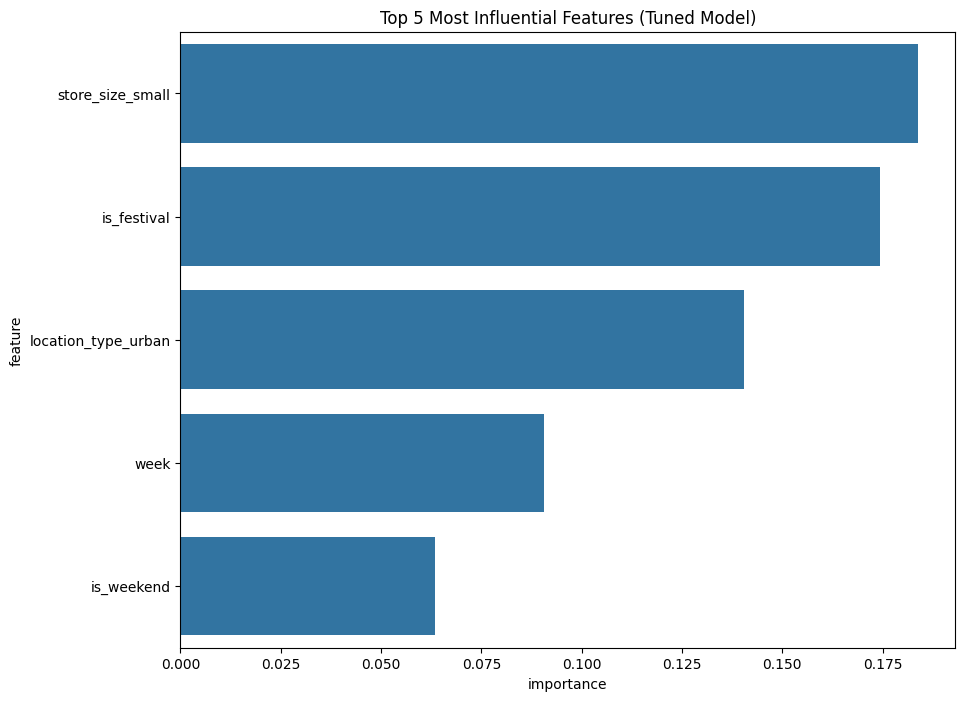

In [14]:
## Feature Importance

feature_names = rf_model.named_steps['columntransformer'].get_feature_names_out()
feature_importances = pd.DataFrame(
    {
        'feature' : feature_names,
        'importance' : rf_model.named_steps['randomforestregressor'].feature_importances_
    }
).sort_values('importance',ascending = False)

print(feature_importances)

top5 = feature_importances.head(5)
print("\nTop 5 Most Influential Features:")
print(top5)

print('\n\n')

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=feature_importances.head(5), x='importance', y='feature', ax=ax)
ax.set_title('Top 5 Most Influential Features (Tuned Model)')
plt.show()

